In [1]:
# Data processing
import pandas as pd
import xarray as xr
import numpy as np
import math

# Plotting 
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask

# Stat and ML
from scipy import stats
from sklearn.model_selection import train_test_split
from tqdm import tqdm 
from statsmodels.tsa.stattools import grangercausalitytests
from scipy.stats import chi2
from sklearn.ensemble import RandomForestRegressor
from scipy.signal import detrend
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.model_selection import cross_val_score, KFold

# Personal library
from models.granger_pca import GrangerPCA
from models.teleconnection_models import RegressionAnalysis, CompositeAnalysis, CanonicalCorrelationAnalysis, SpatialAveraging, PrincipalComponents
from utils.granger_causality_test import test_granger_causality, test_granger_causality_non_parametric
from utils.xarray_numpy import xr2np, np2D_to_np3D
from utils.utils import generate_past_data, lag_analysis, plot_lag_results, compute_aic_bic, explained_variance_ratio_fast
from utils.plot_weights import *

np.random.seed(1234)

## Loading data

In [2]:
ndvi = np.genfromtxt('/home/homer/Documents/Research/Projects/ENSO_NDVI_CD/gpca_ENSO_Africa/dataout/NORTHERN_SOUTH_AMERICA/NDVI/X.tsv')
oscillation = np.genfromtxt('/home/homer/Documents/Research/Projects/ENSO_NDVI_CD/gpca_ENSO_Africa/dataout/NORTHERN_SOUTH_AMERICA/NDVI/Y.tsv')
mask = xr.open_dataset('/home/homer/Documents/Research/Projects/ENSO_NDVI_CD/gpca_ENSO_Africa/dataout/NORTHERN_SOUTH_AMERICA/NDVI/na_mask.nc')
extent = [-83, -60, -14, 14]

# removing masked values
na_mask = mask['na_mask'].values 

# Preprocessing: Removing anomalies
seasonalities = ndvi.reshape(20, 23, -1).mean(axis=0)
ndvi_anomalies = ndvi.reshape(20, 23, -1) - seasonalities

# Preprocessing: Creating a 2D numpy array
anomalies = ndvi_anomalies.reshape(460, -1)
shape = na_mask.shape

# Load and parse datetime index
time = pd.read_csv("time.csv", index_col=0, parse_dates=True)

/tmp/ipykernel_97308/2571533792.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  time = pd.read_csv("time.csv", index_col=0, parse_dates=True)


## Data preprocessing

In [3]:
# Detrending
anomalies = detrend(anomalies, axis=0, type='linear')
oscillation = detrend(oscillation, axis=0, type='linear')

In [4]:
anomalies = (anomalies - anomalies.mean(axis=0))/anomalies.std(axis=0)

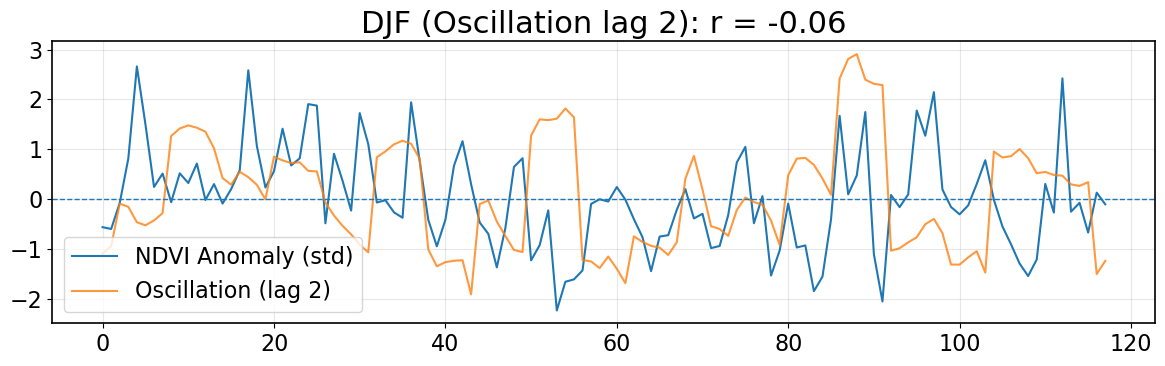

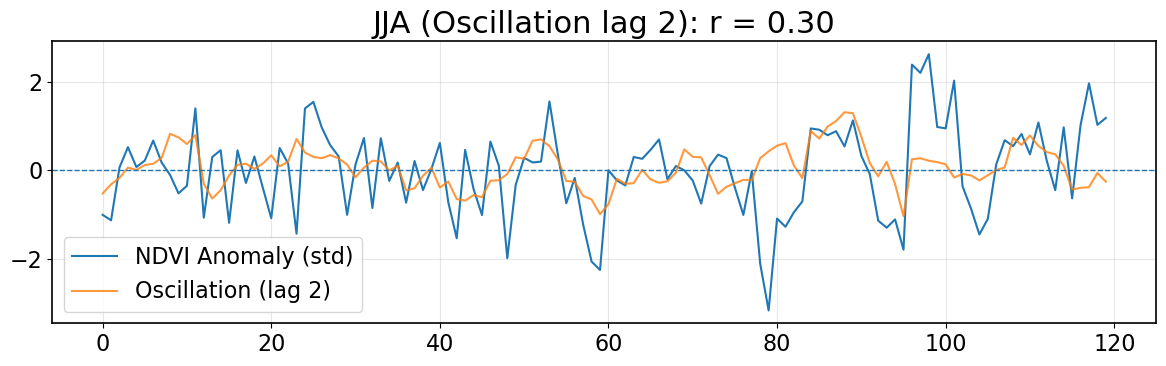

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure datetime index
dates = pd.to_datetime(time.iloc[:, 0])
mean_anom = anomalies.mean(axis=1)

# --- Apply lag manually ---
mean_anom_lag = mean_anom[2:]          # remove first 2
oscillation_lag = oscillation[:-2]     # remove last 2
dates_lag = dates[2:]                  # align with mean_anom_lag

# Build aligned DataFrame
df = pd.DataFrame({
    "mean_anom": mean_anom_lag,
    "oscillation": oscillation_lag
}, index=dates_lag)

# ======================
# DJF
# ======================
djf = df[df.index.month.isin([12, 1, 2])].dropna()

djf_ndvi_std = djf["mean_anom"] / djf["mean_anom"].std()
r_djf = np.corrcoef(djf["mean_anom"], djf["oscillation"])[0, 1]

plt.figure(figsize=(12, 4))
plt.plot(djf_ndvi_std.to_numpy(), linewidth=1.5, label="NDVI Anomaly (std)")
plt.plot(djf["oscillation"].to_numpy(), linewidth=1.5, alpha=0.8, label="Oscillation (lag 2)")

plt.axhline(0, linestyle='--', linewidth=1)
plt.title(f"DJF (Oscillation lag 2): r = {r_djf:.2f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ======================
# JJA
# ======================
jja = df[df.index.month.isin([6, 7, 8])].dropna()

jja_ndvi_std = jja["mean_anom"] / jja["mean_anom"].std()
r_jja = np.corrcoef(jja["mean_anom"], jja["oscillation"])[0, 1]

plt.figure(figsize=(12, 4))
plt.plot(jja_ndvi_std.to_numpy(), linewidth=1.5, label="NDVI Anomaly (std)")
plt.plot(jja["oscillation"].to_numpy(), linewidth=1.5, alpha=0.8, label="Oscillation (lag 2)")

plt.axhline(0, linestyle='--', linewidth=1)
plt.title(f"JJA (Oscillation lag 2): r = {r_jja:.2f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Data splitting
train_ratio = 0.8
    
n = len(anomalies)
train_size = int(n * train_ratio)

anomalies_train = anomalies[:train_size, :]
anomalies_test  = anomalies[train_size:, :]

oscillation_train = oscillation[:train_size]
oscillation_test  = oscillation[train_size:]

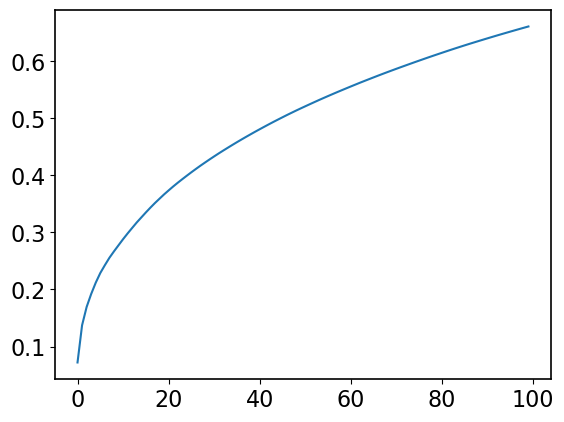

In [7]:
# Principal Component Analysis
ncp = 100
    
pca = PCA(n_components=ncp)
pca.fit(anomalies_train)
plt.plot(np.cumsum(pca.explained_variance_ratio_))


anomalies_pca_train = pca.transform(anomalies_train)
anomalies_pca_test = pca.transform(anomalies_test)

anomalies_pca = pca.transform(anomalies)

## Fitting Granger PCA
* Seting maxlag to *None* to that optimal lag is selected to maximise the *lag_criterion* score of a model predicting $Y$ from $X$ and $Y$'s pasts.
* Different algorithms are available: *diff_ratio* maximise the F-statistic, *ratio* maximise the likelihood ratio and *difference* maximise the RSS difference

In [8]:
lag = 2
mu_grid=np.logspace(-5, 0, 20)
alphas = np.logspace(-5, 20, 100) # Search space for ridge regression hyperparameter
gpca = GrangerPCA(maxlag=lag, maxlags=range(1, 5), method='diff_ratio',#, lag_criterion='r2_median',  #Lag selection
                  model_res=RidgeCV(alphas=alphas), model_full=RidgeCV(alphas=alphas), alpha=1e-7, #Regression models and stabilisation
                  residuals_computation="iid", block_cv_n_blocks=5, # Scheme for computing residuals
                  mu='optimal', mu_grid=mu_grid, test_level=1e-3) #Granger PCA regularisation
gpca.fit(oscillation_train[:, None], anomalies_pca_train, plot_lag_analysis=False, verbose=True)

100%|██████████| 20/20 [00:22<00:00,  1.15s/it]

[GrangerPCA] Optimal mu selected: 2.9764e-01
       eigs
0  0.657897
1  0.236990


In [9]:
cp_test_gpca = gpca.transform(anomalies_pca_test)

## Fitting other algorithms
* Using the same optimal time lag found during Granger PCA analysis 

In [10]:
ca = CompositeAnalysis(maxlag=gpca.maxlag)
ca.fit(oscillation_train[:, None], anomalies_pca_train)
cp_test_ca = ca.transform(anomalies_pca_test, type='PosNeg')

ra = RegressionAnalysis(maxlag=gpca.maxlag)
ra.fit(oscillation_train[:, None], anomalies_pca_train)
cp_test_ra = ra.transform(anomalies_pca_test)

cca = CanonicalCorrelationAnalysis(maxlag=gpca.maxlag, n_components=1)
cca.fit(oscillation_train[:, None], anomalies_pca_train)
cp_test_cca = cca.transform(anomalies_pca_test)

sa = SpatialAveraging()
sa.fit(oscillation_train[:, None], anomalies_train)
cp_test_sa = sa.transform(anomalies_test)

pc = PrincipalComponents()
pc.fit(oscillation_train[:, None], anomalies_train)
cp_test_pc = pc.transform(anomalies_test)

In [11]:
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.stats import t as student_t

def get_weights(anomalies_pca, anomalies, algo, idx=0, mode="correlation"):
    """
    Parameters
    ----------
    anomalies_pca : array-like, shape (n_samples, n_features_pca)
    anomalies : array-like, shape (n_samples, n_pixels)
    algo : fitted PCA-like object with transform method
    idx : int
        Index of component to use
    mode : {"regression", "correlation"}
    
    Returns
    -------
    If mode == "regression":
        coef : array (n_pixels,)
    If mode == "correlation":
        corr : array (n_pixels,)
        sig  : boolean array (n_pixels,) True where significant at 5%
    """

    cp = algo.transform(anomalies_pca)
    if cp.ndim > 1 and cp.shape[1] > 1:
        cp = cp[:, idx]

    if mode == "regression":
        lr = LinearRegression()
        lr.fit(anomalies, cp)
        return lr.coef_

    elif mode == "correlation":
        cp = np.asarray(cp).ravel()
        n = cp.size

        # Center
        cp_c = cp - cp.mean()
        anomalies_c = anomalies - anomalies.mean(axis=0)

        # Norms
        cp_norm = np.sqrt(np.sum(cp_c**2))
        anomalies_norm = np.sqrt(np.sum(anomalies_c**2, axis=0))

        # Covariance
        cov = np.sum(anomalies_c * cp_c[:, None], axis=0)

        # Correlation
        corr = cov / (cp_norm * anomalies_norm)

        # ---- Significance test (two-sided, alpha=0.05) ----
        df = n - 2
        t_stat = corr * np.sqrt(df / (1 - corr**2))
        p_values = 2 * (1 - student_t.cdf(np.abs(t_stat), df))

        significance = p_values < 0.05

        return corr, significance

    else:
        raise ValueError(f"Unknown mode '{mode}'. Use 'regression' or 'correlation'.")


corr_ca, significance_ca = get_weights(anomalies_pca, anomalies, ca)
corr_ra, significance_ra  = get_weights(anomalies_pca, anomalies, ra)
corr_cca, significance_cca  = get_weights(anomalies_pca, anomalies, cca)
corr_pc, significance_pc  = get_weights(anomalies, anomalies, pc)
corr_sa, significance_sa  = get_weights(anomalies, anomalies, sa)
idx = 0 # Which GPC
corr_gpca, significance_gpca  = get_weights(anomalies_pca, anomalies, gpca, idx=0)

In [12]:
idx = 0 # Which GPC
weights_gpca = get_weights(anomalies_pca, anomalies, gpca, idx=0)

## Testing Granger causality 
* We test Granger causality between the extracted component $\tilde{Y}$ and the climate oscillation $X$

In [13]:
w_gpca = np.ravel(corr_gpca)#[0, :]#(gpca.vects_[:, idx] @ pca.components_)
w_ra = np.ravel(corr_ra)
w_ca = np.ravel(corr_ca)#ca.composites['PosNeg'].to_numpy() @ pca.components_
w_cca = np.ravel(corr_cca)#(cca.cca.y_rotations_.T @ pca.components_)[0, :]
w_sa = np.ravel(corr_sa)
w_pc = np.ravel(corr_pc)#pca.components_[0, :]

In [14]:
w_gpca.shape, w_cca.shape

((9421,), (9421,))

In [15]:
results_gpca = test_granger_causality(oscillation_test[:, None], cp_test_gpca[:, idx], maxlag=[gpca.maxlag])
results_ra = test_granger_causality(oscillation_test[:, None], cp_test_ra, maxlag=[gpca.maxlag])
results_ca = test_granger_causality(oscillation_test[:, None], cp_test_ca, maxlag=[gpca.maxlag])
results_cca = test_granger_causality(oscillation_test[:, None], cp_test_cca, maxlag=[gpca.maxlag])
results_sa = test_granger_causality(oscillation_test[:, None], cp_test_sa, maxlag=[gpca.maxlag])
results_pc = test_granger_causality(oscillation_test[:, None], cp_test_pc, maxlag=[gpca.maxlag])

### Results

In [16]:
import pandas as pd

# ============================================================
# 1. Compute explained variance ratio (scalar per method)
# ============================================================
evr_gpca = explained_variance_ratio_fast(anomalies_test, w_gpca)
evr_cca  = explained_variance_ratio_fast(anomalies_test, w_cca)
evr_ca   = explained_variance_ratio_fast(anomalies_test, w_ca)
evr_ra   = explained_variance_ratio_fast(anomalies_test, w_ra)
evr_sa   = explained_variance_ratio_fast(anomalies_test, w_sa)
evr_pc   = explained_variance_ratio_fast(anomalies_test, w_pc)


# ============================================================
# 2. Attach EVR to each results DataFrame (scalar broadcast)
# ============================================================
results_gpca = results_gpca.assign(EVR=evr_gpca)
results_cca  = results_cca.assign(EVR=evr_cca)
results_ca   = results_ca.assign(EVR=evr_ca)
results_ra   = results_ra.assign(EVR=evr_ra)
results_sa   = results_sa.assign(EVR=evr_sa)
results_pc   = results_pc.assign(EVR=evr_pc)


# ============================================================
# 3. Combine results at the selected lag
# ============================================================
combined = pd.concat(
    [
        results_gpca[results_gpca['lag'] == gpca.maxlag],
        results_cca[results_cca['lag'] == gpca.maxlag],
        results_ca[results_ca['lag'] == gpca.maxlag],
        results_ra[results_ra['lag'] == gpca.maxlag],
        results_sa[results_sa['lag'] == gpca.maxlag],
        results_pc[results_pc['lag'] == gpca.maxlag],
    ],
    keys=['GPCA', 'CCA', 'Composites', 'Regression', 'Spatial Average', 'PCA']
).reset_index(level=0).rename(columns={'level_0': 'Method'})

# ============================================================
# 4. Export to LaTeX (include EVR)
# ============================================================
latex_table = combined[['EVR', 'F_statistic', 'p_value']].to_latex(
    index=True,
    caption=f"Comparison of Results by Method at lag = {gpca.maxlag}",
    label="tab:results_by_method",
    float_format="%.6f",
    escape=True
)

# ============================================================
# 5. Save LaTeX table to file
# ============================================================
output_path = (
    f"tables/teleconnection_pvalues_NDVI_"
    f"Northern South America_coarsen-_lag-{gpca.maxlag}.tex"
)

with open(output_path, "w") as f:
    f.write(latex_table)

In [17]:
combined

,Method,lag,Y_column,F_statistic,df1,df2,p_value,F_critical,alpha_used,interpretation,EVR
0,GPCA,2,1,4.663935,2,86,0.011939,3.102552,0.05,Reject H₀ (α=0.05000): X Granger-causes Y (lag=2),0.041022
0,CCA,2,1,5.500461,2,86,0.005650,3.102552,0.05,Reject H₀ (α=0.05000): X Granger-causes Y (lag=2),0.045910
0,Composites,2,1,5.157519,2,86,0.007666,3.102552,0.05,Reject H₀ (α=0.05000): X Granger-causes Y (lag=2),0.044691
0,Regression,2,1,5.064198,2,86,0.008333,3.102552,0.05,Reject H₀ (α=0.05000): X Granger-causes Y (lag=2),0.044737
0,Spatial Average,2,1,0.178165,2,86,0.837113,3.102552,0.05,Fail to reject H₀: no Granger causality for Y ...,0.063386
0,PCA,2,1,2.087312,2,86,0.130259,3.102552,0.05,Fail to reject H₀: no Granger causality for Y ...,0.049733


In [18]:
idx = 0 # Which GPC

weights_gpca = w_gpca
weights_ra = w_ra
weights_ca = w_ca
weights_cca = w_cca
weights_sa = w_sa
weights_pc = w_pc

weights = {'GPCA':{'weights':weights_gpca, 'significances':significance_gpca, 'p-value':results_gpca[results_gpca['lag']==gpca.maxlag]['p_value']}, 
            'Regression':{'weights':weights_ra, 'significances':significance_ra, 'p-value':results_ra[results_ra['lag']==gpca.maxlag]['p_value']},
            'Composites':{'weights':weights_ca, 'significances':significance_ca, 'p-value':results_ca[results_ca['lag']==gpca.maxlag]['p_value']},
            'CCA':{'weights':weights_cca, 'significances':significance_cca, 'p-value':results_cca[results_cca['lag']==gpca.maxlag]['p_value']},
            'PCA':{'weights':weights_pc, 'significances':significance_pc, 'p-value':results_pc[results_pc['lag']==gpca.maxlag]['p_value']},
            'Average':{'weights':weights_sa, 'significances':significance_sa, 'p-value':results_sa[results_sa['lag']==gpca.maxlag]['p_value']},
        }

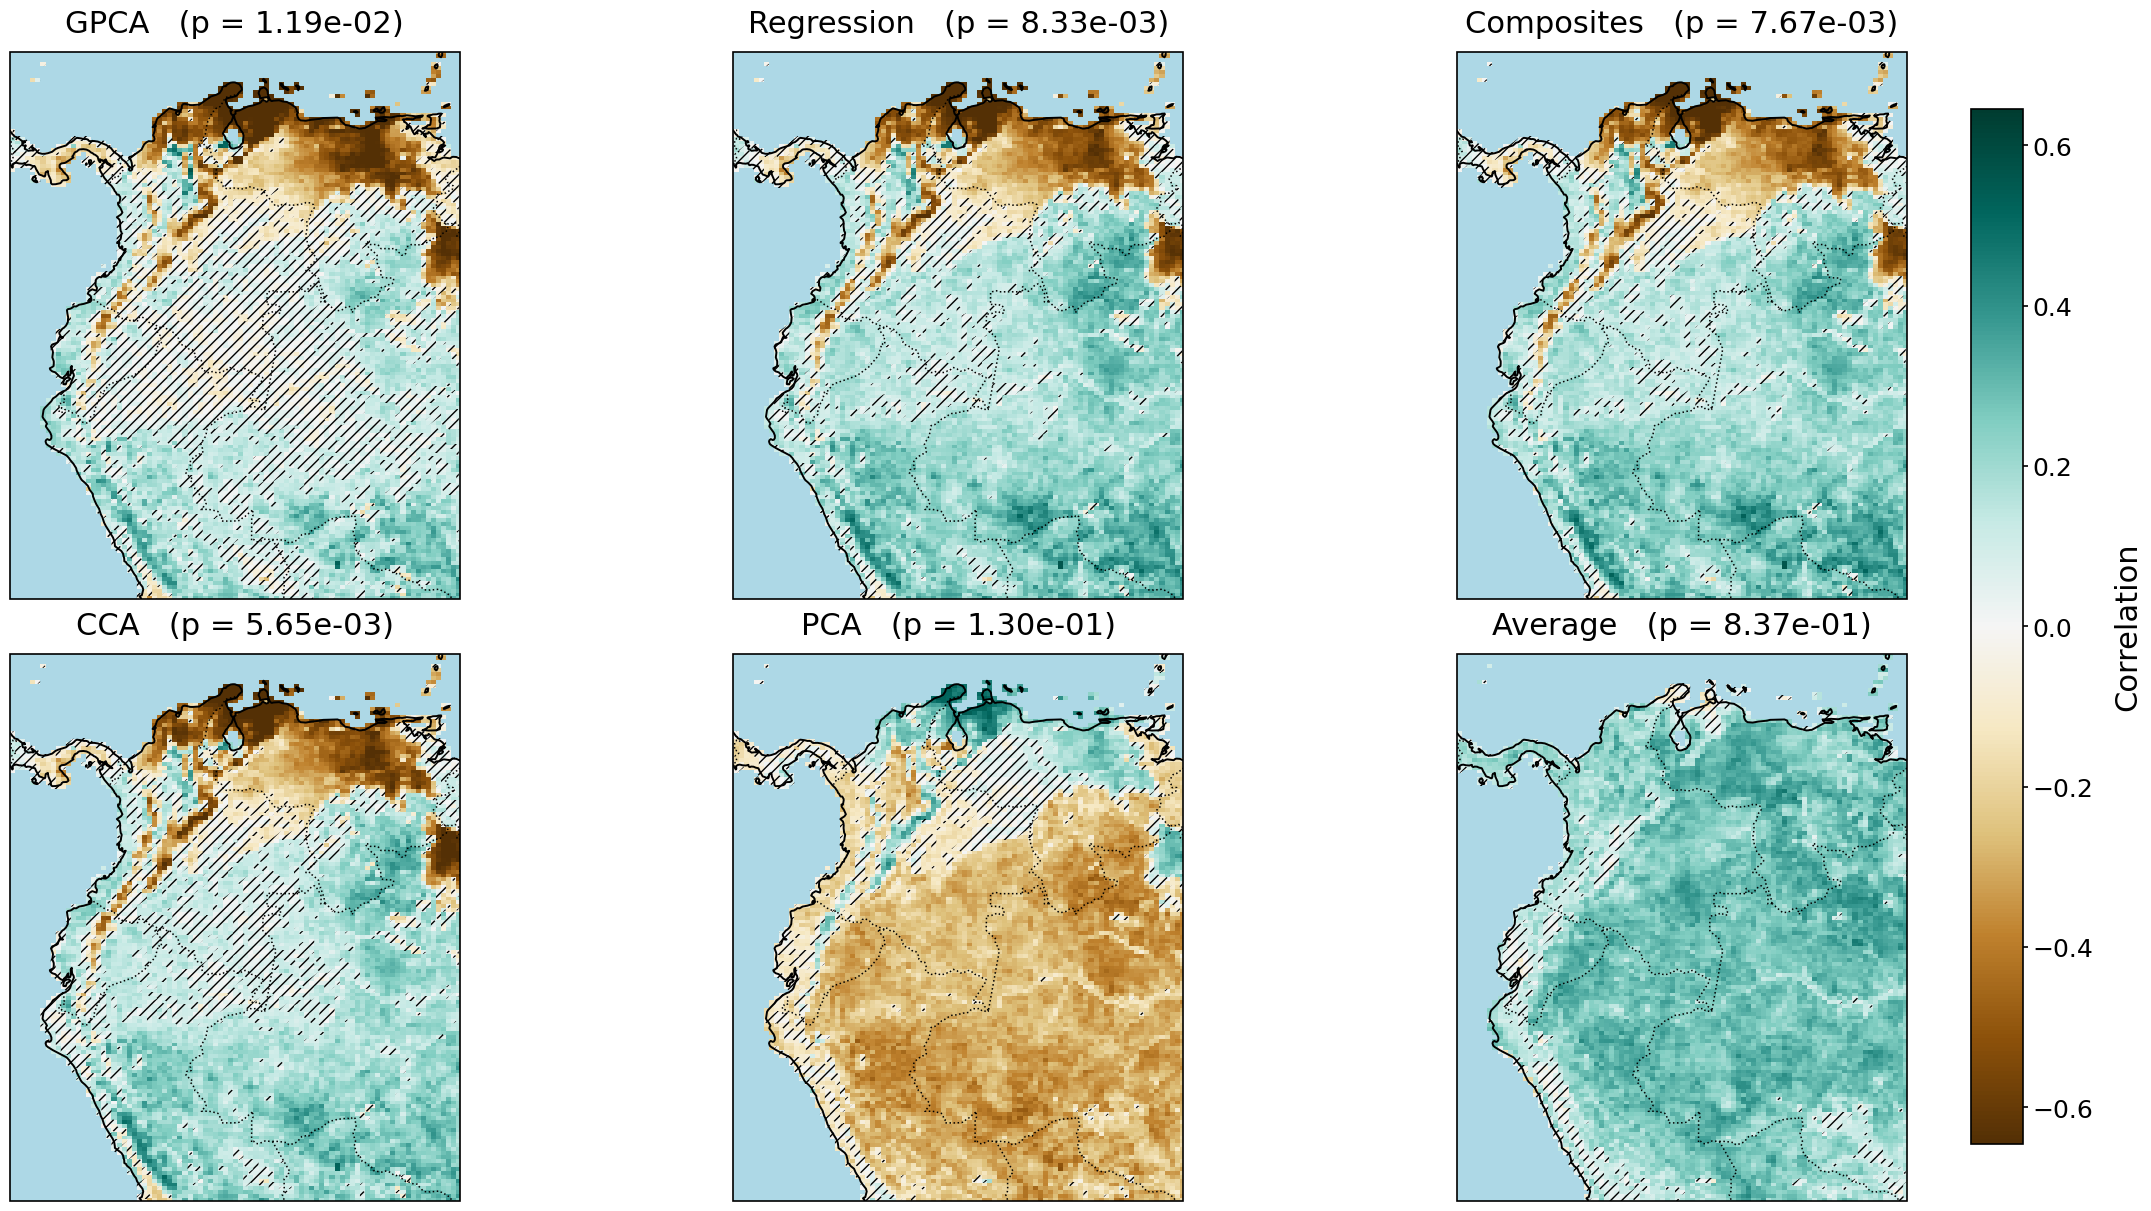

In [19]:
path = f'figures/teleconnection_weights_NDVI_Northern South America_lag-{gpca.maxlag}.pdf'

easting = mask.easting.values
northing = mask.northing.values
plot_weight_maps(weights, 'NDVI', lon=None, lat=None, extent=extent, easting=easting, northing=northing, save_path=path, na_mask=na_mask, cmap='BrBG')

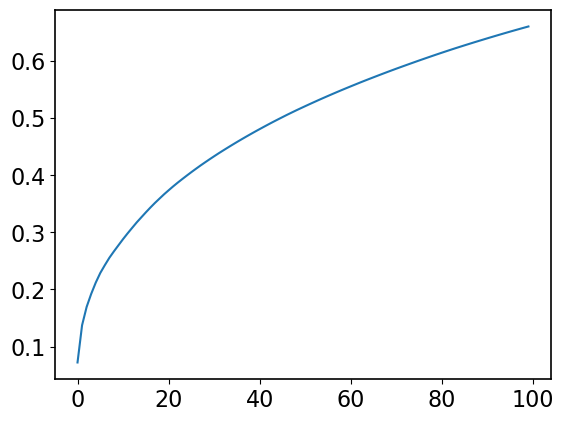

In [20]:
# Principal Component Analysis
ncp = 100
    
pca = PCA(n_components=ncp)
pca.fit(anomalies_train)
plt.plot(np.cumsum(pca.explained_variance_ratio_))


anomalies_pca_train = pca.transform(anomalies_train)
anomalies_pca_test = pca.transform(anomalies_test)

anomalies_pca = pca.transform(anomalies)

In [30]:
lags = [1, 2]
mu_grid = np.logspace(-5, 0, 40)
weights = {'GPCA-'+str(lag):{} for lag in lags}
alphas=np.logspace(-5, 20, 100)
EVRs = {'train':[], 'test':[]}
F_stats = {'train':[], 'test':[]}


for lag in tqdm(lags):
    gpca = GrangerPCA(maxlag=lag, method='diff_ratio',# maxlags=range(1, 5), lag_criterion='r2_median',  #Lag selection
                  model_res=RidgeCV(alphas=alphas), model_full=RidgeCV(alphas=alphas), alpha=1e-4, #Regression models and stabilisation
                  residuals_computation="block_cv", block_cv_n_blocks=5, # Scheme for computing residuals
                  mu='optimal', mu_grid=mu_grid, test_level=1e-1) #Granger PCA regularisation
    gpca.fit(oscillation_train[:, None], anomalies_pca_train, plot_lag_analysis=False, verbose=False)
    cp_test_gpca = gpca.transform(anomalies_pca_test)
    cp_train_gpca = gpca.transform(anomalies_pca_train)
    
    weights_gpca_train, _ = get_weights(anomalies_pca_train, anomalies_train, gpca, idx=0)
    weights_gpca_test, _ = get_weights(anomalies_pca_test, anomalies_test, gpca, idx=0)
    weights_gpca, significance = get_weights(anomalies_pca, anomalies, gpca, idx=0)

    
    results_gpca = test_granger_causality(oscillation_train[:, None], cp_train_gpca[:, 0], maxlag=[lag])
    F_train = results_gpca[results_gpca['lag'] == lag]['F_statistic'][0]
    
    results_gpca = test_granger_causality(oscillation_test[:, None], cp_test_gpca[:, 0], maxlag=[lag])
    F_test = results_gpca[results_gpca['lag'] == lag]['F_statistic'][0]
    
    weights_gpca_train = np.ravel(weights_gpca_train)
    weights_gpca_test = np.ravel(weights_gpca_test)
    weights_gpca = np.ravel(weights_gpca)

    evr_train = explained_variance_ratio_fast(anomalies_test, weights_gpca_train)
    evr_test = explained_variance_ratio_fast(anomalies_test, weights_gpca_test)
    
    weights_gpca_test = weights_gpca_test
    
    weights['GPCA-'+str(lag)] = {'weights':weights_gpca, 'p-value':results_gpca[results_gpca['lag']==gpca.maxlag]['p_value'], 'significances':significance}
    
    EVRs['train'].append(evr_train)
    EVRs['test'].append(evr_test)
    
    F_stats['train'].append(F_train)
    F_stats['test'].append(F_test)
    
    print(f'Selected mu {gpca.mu}')
    print(f'EVR train {evr_train}, test {evr_test}')
    print(f'F_stat train {F_train}, test {F_test}')

  0%|          | 0/2 [00:00<?, ?it/s]

 50%|█████     | 1/2 [00:58<00:58, 58.77s/it]

Selected mu 0.7443803013251681
EVR train 0.04236048668245793, test 0.08303291335119238
F_stat train 13.664926010050783, test 7.726925239039046


100%|██████████| 2/2 [02:40<00:00, 80.50s/it]

Selected mu 0.7443803013251681
EVR train 0.04208171691259283, test 0.0832364162847717
F_stat train 9.171928707388068, test 4.088745819809186


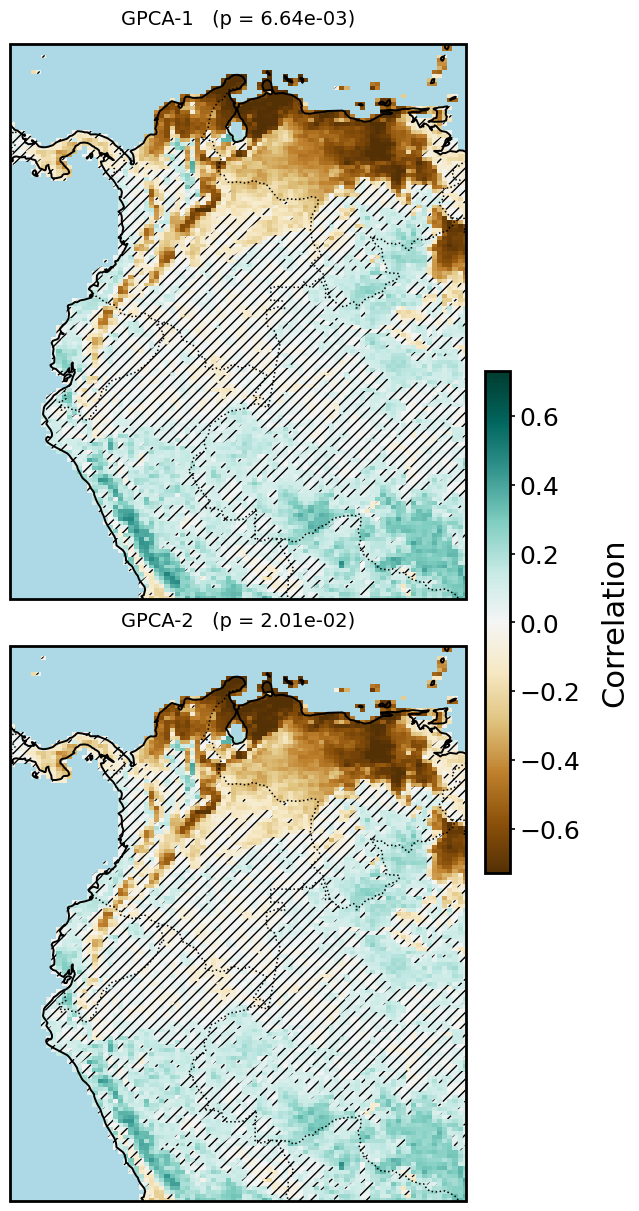

In [31]:
path = f'figures/teleconnection_weights_NDVI_Northern South America_lags1-2.png'
plot_weight_maps(weights, 'NDVI', lon=None, lat=None, extent=extent, easting=easting, northing=northing, save_path=path, na_mask=na_mask, cmap='BrBG')

In [32]:
lags = np.arange(1, 20)

results_gpca = test_granger_causality(oscillation_test[:, None], cp_test_gpca[:, 0], maxlag=lags)
results_ra = test_granger_causality(oscillation_test[:, None], cp_test_ra, maxlag=lags)
results_ca = test_granger_causality(oscillation_test[:, None], cp_test_ca, maxlag=lags)
results_cca = test_granger_causality(oscillation_test[:, None], cp_test_cca, maxlag=lags)
results_sa = test_granger_causality(oscillation_test[:, None], cp_test_sa, maxlag=lags)
results_pc = test_granger_causality(oscillation_test[:, None], cp_test_pc, maxlag=lags)

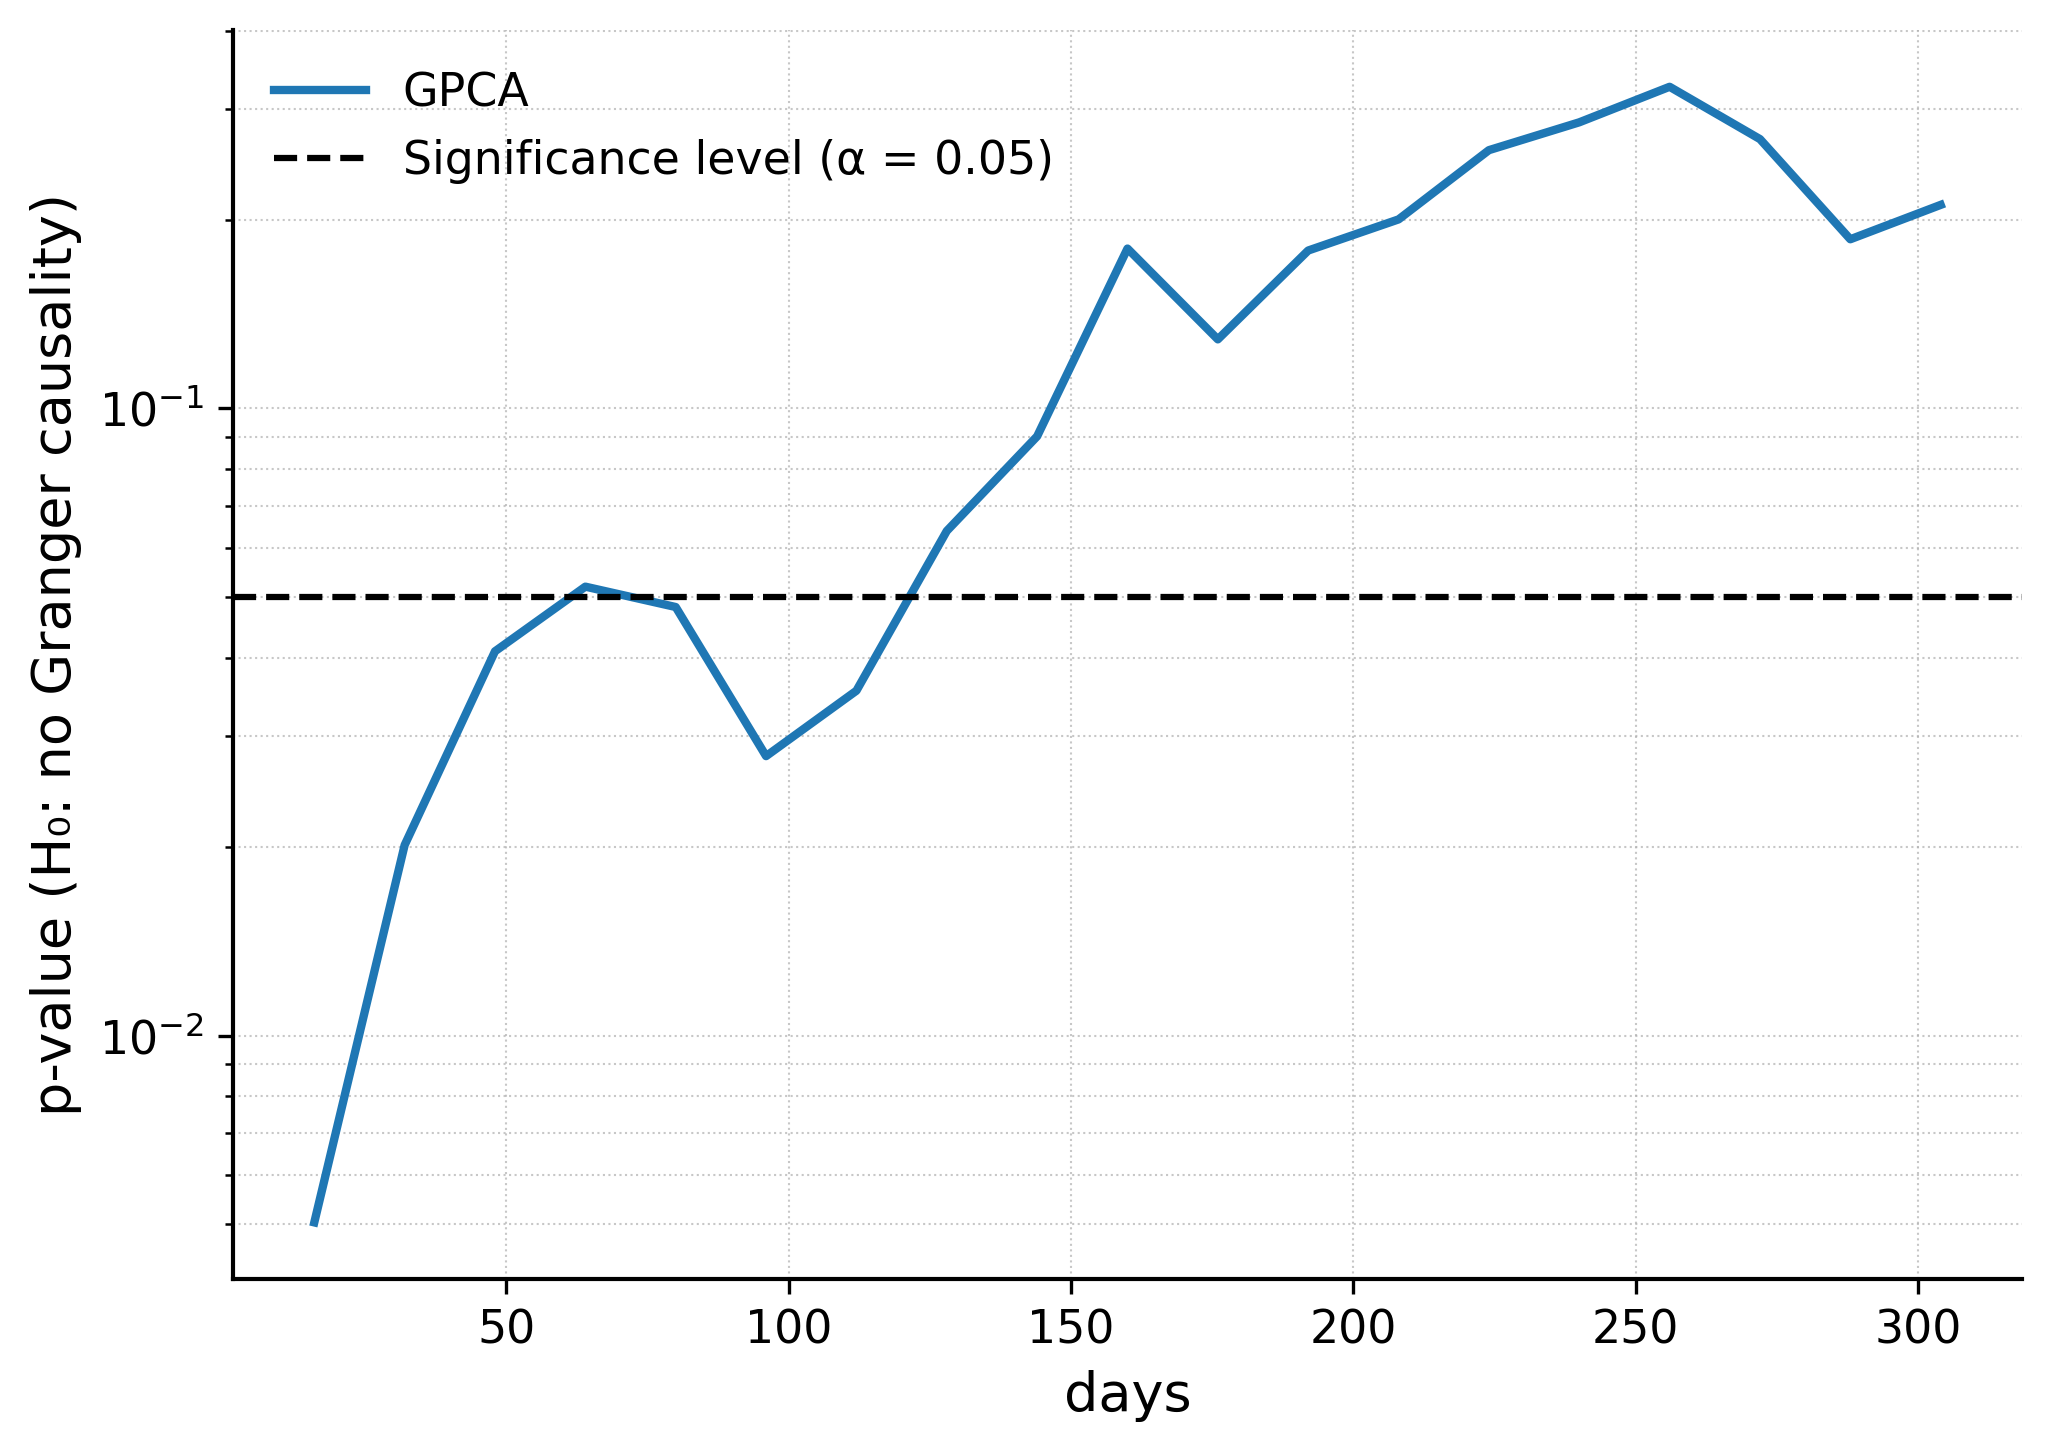

In [33]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- Global style adjustments ---
mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 1.0,
    "lines.linewidth": 2.0,
})

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

# --- Plot lines ---
ax.plot(lags*16, results_gpca['p_value'], label='GPCA')

# --- Rejection threshold ---
ax.axhline(
    y=0.05,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label='Significance level (α = 0.05)'
)

# --- Axes formatting ---
ax.set_xlabel('days')
ax.set_ylabel('p-value (H₀: no Granger causality)')
ax.set_yscale('log')

# Optional: improve log tick formatting
ax.yaxis.set_major_formatter(mpl.ticker.LogFormatterMathtext())

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Subtle grid
ax.grid(True, which='both', linestyle=':', linewidth=0.5, alpha=0.7)

# Legend outside if many lines
ax.legend(frameon=False, loc='best')

plt.tight_layout()

# Save for publication (vector format preferred)
plt.savefig(f"figures/granger_pvalues_NSA_lag.png", dpi=600, bbox_inches='tight')

plt.show()

In [25]:
weights["GPCA-1"]["significances"]  # 1D vector


array([False, False,  True, ...,  True,  True,  True])

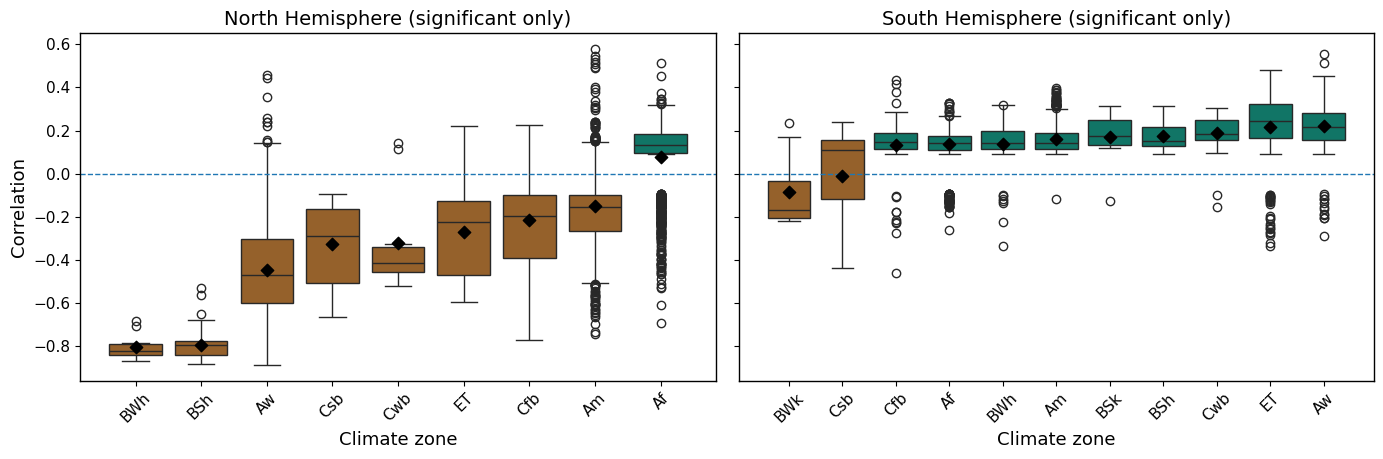

In [26]:
# ======================================================================
# Imports
# ======================================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import rasterio
from pyproj import Transformer


# ======================================================================
# Constants
# ======================================================================

CLIMATE_TIF = "data/koppen_geiger_0p1.tif"

KOPPEN_NAMES = {
    1: "Af", 2: "Am", 3: "Aw",
    4: "BWh", 5: "BWk", 6: "BSh", 7: "BSk",
    8: "Csa", 9: "Csb", 10: "Csc",
    11: "Cwa", 12: "Cwb", 13: "Cwc",
    14: "Cfa", 15: "Cfb", 16: "Cfc",
    17: "Dsa", 18: "Dsb", 19: "Dsc", 20: "Dsd",
    21: "Dwa", 22: "Dwb", 23: "Dwc", 24: "Dwd",
    25: "Dfa", 26: "Dfb", 27: "Dfc", 28: "Dfd",
    29: "ET", 30: "EF"
}


# ======================================================================
# Extract weights and significances
# ======================================================================

corr = weights["GPCA-1"]["weights"]
sig = np.array(weights["GPCA-1"]["significances"], dtype=bool)


# ======================================================================
# Reconstruct 2D fields (MATCHES YOUR PLOTTING LOGIC EXACTLY)
# ======================================================================

# Weights
corr_2d = np.zeros_like(na_mask, dtype=float).T
corr_2d[na_mask.T == 1] = corr
corr_2d[na_mask.T == 0] = np.nan
corr_2d = corr_2d.T

# Significance
sig_2d = np.zeros_like(na_mask, dtype=bool).T
sig_2d[na_mask.T == 1] = sig
sig_2d[na_mask.T == 0] = False
sig_2d = sig_2d.T


# ======================================================================
# Build Lon/Lat Grid (same convention as plotting)
# ======================================================================

transformer = Transformer.from_crs(
    "EPSG:6933",
    "EPSG:4326",
    always_xy=True
)

e2d, n2d = np.meshgrid(easting, northing, indexing="ij")
lon2d, lat2d = transformer.transform(e2d, n2d)

lon2d = lon2d.T
lat2d = lat2d.T


# ======================================================================
# Apply SIGNIFICANCE MASK (CRITICAL)
# ======================================================================

valid_mask = np.isfinite(corr_2d) & sig_2d

lons = lon2d[valid_mask]
lats = lat2d[valid_mask]
corr_vals = corr_2d[valid_mask]


# ======================================================================
# Sample Climate Raster
# ======================================================================

with rasterio.open(CLIMATE_TIF) as src:
    climate = src.read(1)
    climate_transform = src.transform
    nodata = src.nodata

if nodata is not None:
    climate = np.where(climate == nodata, np.nan, climate)

rows, cols = rasterio.transform.rowcol(climate_transform, lons, lats)

rows = np.asarray(rows)
cols = np.asarray(cols)

in_bounds = (
    (rows >= 0) & (rows < climate.shape[0]) &
    (cols >= 0) & (cols < climate.shape[1])
)

climate_classes = np.full(len(lons), np.nan)
climate_classes[in_bounds] = climate[rows[in_bounds], cols[in_bounds]]

valid_final = in_bounds & np.isfinite(climate_classes)


# ======================================================================
# Build DataFrame
# ======================================================================

df = pd.DataFrame({
    "correlation": corr_vals[valid_final],
    "latitude": lats[valid_final],
    "climate_code": climate_classes[valid_final].astype(int)
})

df["climate"] = df["climate_code"].map(
    lambda c: KOPPEN_NAMES.get(c, f"Unknown_{c}")
)

df["hemisphere"] = np.where(df["latitude"] >= 0, "North", "South")


# ======================================================================
# Plot
# ======================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, hemi in zip(axes, ["North", "South"]):

    df_sub = df[df["hemisphere"] == hemi]

    means = df_sub.groupby("climate")["correlation"].mean()
    order = means.sort_values().index

    palette = {
        climate: ("#A6611A" if mean < 0 else "#018571")
        for climate, mean in means.items()
    }

    sns.boxplot(
        data=df_sub,
        x="climate",
        y="correlation",
        order=order,
        hue="climate",
        palette=palette,
        legend=False,
        ax=ax
    )

    ax.axhline(0, linestyle="--", linewidth=1)

    ax.scatter(
        np.arange(len(order)),
        means.loc[order].values,
        marker="D",
        s=40,
        zorder=3,
        color='black'
    )

    ax.set_title(f"{hemi} Hemisphere (significant only)")
    ax.set_xlabel("Climate zone")
    ax.tick_params(axis="x", rotation=45)

axes[0].set_ylabel("Correlation")
axes[1].set_ylabel("")

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("figures/Correlation_GPCA_NDVI_Climate_zones_by_hemisphere_SIGNIFICANT.png")
plt.show()

/tmp/ipykernel_97308/1202742328.py:164: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_97308/1202742328.py:164: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


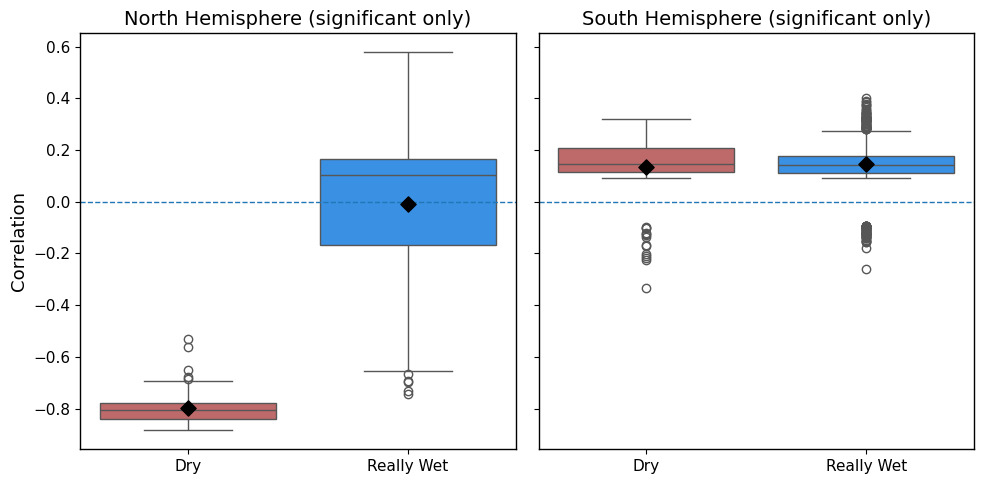

In [27]:
# ======================================================================
# Imports
# ======================================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import rasterio
from pyproj import Transformer


# ======================================================================
# Constants
# ======================================================================

CLIMATE_TIF = "data/koppen_geiger_0p1.tif"

KOPPEN_NAMES = {
    1: "Af", 2: "Am", 3: "Aw",
    4: "BWh", 5: "BWk", 6: "BSh", 7: "BSk",
    8: "Csa", 9: "Csb", 10: "Csc",
    11: "Cwa", 12: "Cwb", 13: "Cwc",
    14: "Cfa", 15: "Cfb", 16: "Cfc",
    17: "Dsa", 18: "Dsb", 19: "Dsc", 20: "Dsd",
    21: "Dwa", 22: "Dwb", 23: "Dwc", 24: "Dwd",
    25: "Dfa", 26: "Dfb", 27: "Dfc", 28: "Dfd",
    29: "ET", 30: "EF"
}


# ======================================================================
# Extract weights and significances
# ======================================================================

corr = weights["GPCA-1"]["weights"]
sig = np.array(weights["GPCA-1"]["significances"], dtype=bool)


# ======================================================================
# Reconstruct 2D fields
# ======================================================================

corr_2d = np.zeros_like(na_mask, dtype=float).T
corr_2d[na_mask.T == 1] = corr
corr_2d[na_mask.T == 0] = np.nan
corr_2d = corr_2d.T

sig_2d = np.zeros_like(na_mask, dtype=bool).T
sig_2d[na_mask.T == 1] = sig
sig_2d[na_mask.T == 0] = False
sig_2d = sig_2d.T


# ======================================================================
# Build Lon/Lat Grid
# ======================================================================

transformer = Transformer.from_crs(
    "EPSG:6933",
    "EPSG:4326",
    always_xy=True
)

e2d, n2d = np.meshgrid(easting, northing, indexing="ij")
lon2d, lat2d = transformer.transform(e2d, n2d)

lon2d = lon2d.T
lat2d = lat2d.T


# ======================================================================
# Apply SIGNIFICANCE MASK
# ======================================================================

valid_mask = np.isfinite(corr_2d) & sig_2d

lons = lon2d[valid_mask]
lats = lat2d[valid_mask]
corr_vals = corr_2d[valid_mask]


# ======================================================================
# Sample Climate Raster
# ======================================================================

with rasterio.open(CLIMATE_TIF) as src:
    climate = src.read(1)
    climate_transform = src.transform
    nodata = src.nodata

if nodata is not None:
    climate = np.where(climate == nodata, np.nan, climate)

rows, cols = rasterio.transform.rowcol(climate_transform, lons, lats)

rows = np.asarray(rows)
cols = np.asarray(cols)

in_bounds = (
    (rows >= 0) & (rows < climate.shape[0]) &
    (cols >= 0) & (cols < climate.shape[1])
)

climate_classes = np.full(len(lons), np.nan)
climate_classes[in_bounds] = climate[rows[in_bounds], cols[in_bounds]]

valid_final = in_bounds & np.isfinite(climate_classes)


# ======================================================================
# Build DataFrame
# ======================================================================

df = pd.DataFrame({
    "correlation": corr_vals[valid_final],
    "latitude": lats[valid_final],
    "climate_code": climate_classes[valid_final].astype(int)
})

df["climate"] = df["climate_code"].map(
    lambda c: KOPPEN_NAMES.get(c, f"Unknown_{c}")
)

df["hemisphere"] = np.where(df["latitude"] >= 0, "North", "South")


# ======================================================================
# STRICT Dry vs Really Wet definition
# Dry = all B climates
# Really Wet = Af and Am only
# ======================================================================

dry_classes = ["BWh", "BWk", "BSh", "BSk"]
wet_classes = ["Af", "Am"]

df = df[df["climate"].isin(dry_classes + wet_classes)].copy()

df["climate_group"] = np.where(
    df["climate"].isin(dry_classes),
    "Dry",
    "Really Wet"
)


# ======================================================================
# Plot
# ======================================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

palette = {
    "Dry": "#CD5C5C",
    "Really Wet": "#1E90FF"
}

for ax, hemi in zip(axes, ["North", "South"]):

    df_sub = df[df["hemisphere"] == hemi]

    means = df_sub.groupby("climate_group")["correlation"].mean()
    order = ["Dry", "Really Wet"]

    sns.boxplot(
        data=df_sub,
        x="climate_group",
        y="correlation",
        order=order,
        palette=palette,
        ax=ax
    )

    ax.axhline(0, linestyle="--", linewidth=1)

    ax.scatter(
        np.arange(len(order)),
        means.reindex(order).values,
        marker="D",
        s=60,
        color="black",
        zorder=3
    )

    ax.set_title(f"{hemi} Hemisphere (significant only)")
    ax.set_xlabel("")
    ax.set_ylabel("Correlation")

plt.tight_layout()
plt.savefig("figures/Correlation_GPCA_Dry_vs_ReallyWet_by_Hemisphere.png")
plt.show()

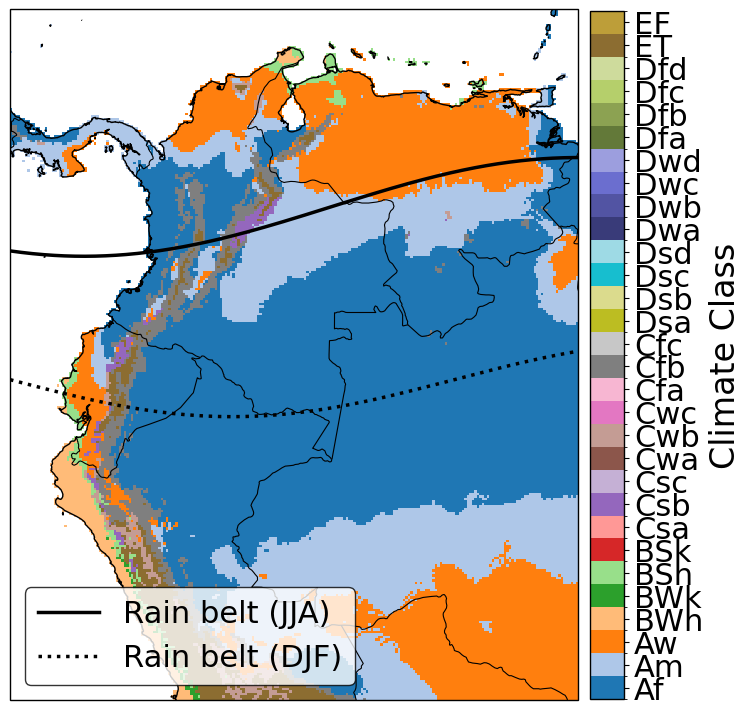

In [28]:
# ======================================================================
# Imports
# ======================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ======================================================================
# Global matplotlib settings for publication quality
# ======================================================================

plt.rcParams.update({
    "font.size": 24,
    "axes.labelsize": 26,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 22,
})

# ======================================================================
# Map settings
# ======================================================================

extent = [-83, -60, -14, 14]

# ======================================================================
# Köppen names (Beck 2018)
# ======================================================================

KOPPEN_NAMES = {
    1: "Af", 2: "Am", 3: "Aw",
    4: "BWh", 5: "BWk", 6: "BSh", 7: "BSk",
    8: "Csa", 9: "Csb", 10: "Csc",
    11: "Cwa", 12: "Cwb", 13: "Cwc",
    14: "Cfa", 15: "Cfb", 16: "Cfc",
    17: "Dsa", 18: "Dsb", 19: "Dsc", 20: "Dsd",
    21: "Dwa", 22: "Dwb", 23: "Dwc", 24: "Dwd",
    25: "Dfa", 26: "Dfb", 27: "Dfc", 28: "Dfd",
    29: "ET", 30: "EF"
}

# ======================================================================
# Unique classes (ignore 0 if nodata)
# ======================================================================

unique_classes = np.unique(climate)
unique_classes = unique_classes[unique_classes > 0].astype(int)

# ======================================================================
# Create categorical colors
# ======================================================================

colors = (
    list(plt.get_cmap("tab20").colors) +
    list(plt.get_cmap("tab20b").colors) +
    list(plt.get_cmap("tab20c").colors)
)

colors = colors[:len(unique_classes)]
cmap = mcolors.ListedColormap(colors)

bounds = np.arange(unique_classes.min(), unique_classes.max() + 2)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# ======================================================================
# Plot
# ======================================================================

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent(extent, crs=ccrs.PlateCarree())

im = ax.imshow(
    climate,
    origin="upper",
    extent=[
        climate_transform.c,
        climate_transform.c + climate_transform.a * climate.shape[1],
        climate_transform.f + climate_transform.e * climate.shape[0],
        climate_transform.f
    ],
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    interpolation="nearest"
)

# Improved coastlines and borders
ax.coastlines(resolution="10m", linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)

# ======================================================================
# Tropical rain belt (ITCZ) lines
# ======================================================================

lon = np.linspace(extent[0], extent[1], 500)

lat_jja = 6 + 2*np.sin((lon + 70) * np.pi / 20)
lat_djf = -1 + 1.5*np.sin((lon + 65) * np.pi / 18)

ax.plot(
    lon, lat_jja,
    color="black",
    linestyle="-",
    linewidth=2.5,
    label="Rain belt (JJA)"
)

ax.plot(
    lon, lat_djf,
    color="black",
    linestyle=":",
    linewidth=2.5,
    label="Rain belt (DJF)"
)

ax.legend(
    loc="lower left",
    frameon=True,
    edgecolor="black"
)

# ======================================================================
# Categorical colorbar
# ======================================================================

cbar = plt.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    fraction=0.056,
    pad=0.02
)

cbar.set_ticks(unique_classes + 0.5)
cbar.set_ticklabels([KOPPEN_NAMES.get(c, str(c)) for c in unique_classes])
cbar.set_label("Climate Class", fontsize=24)

plt.tight_layout()
plt.savefig('figures/Climate_zones_NSA.png', dpi=300, bbox_inches='tight')
plt.show()

KeyError: 'oscillation'

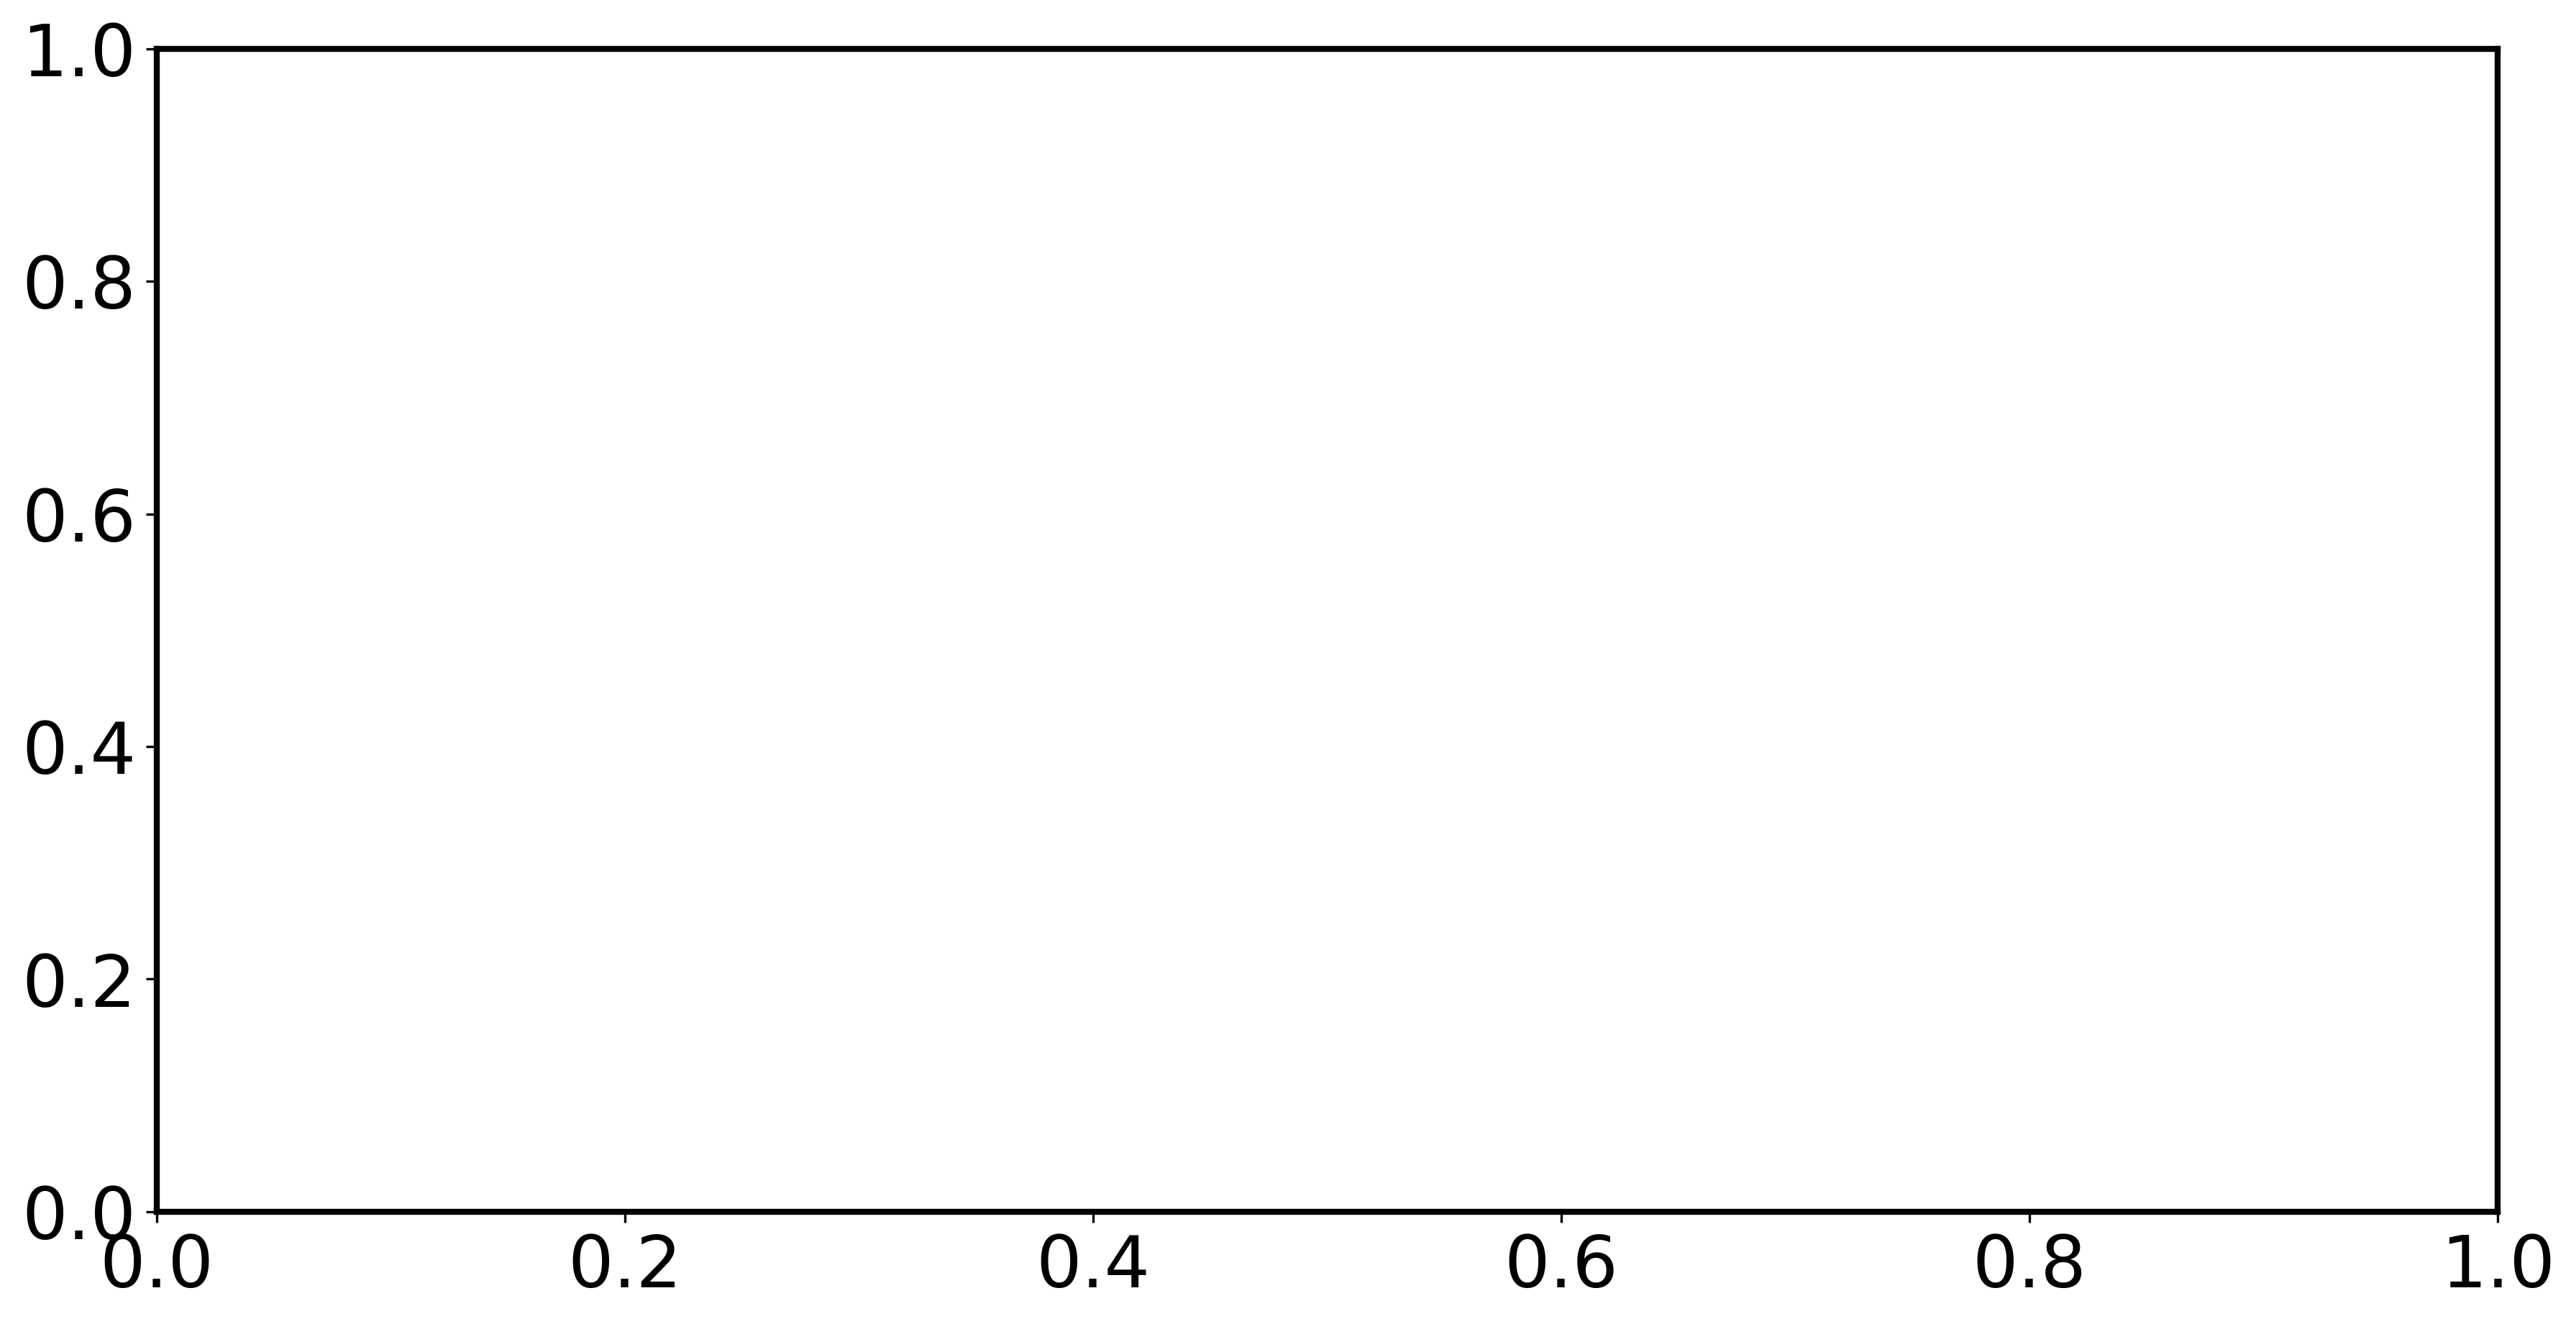

In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.patches import Patch

# Ensure datetime index
df = df.copy()
df.index = pd.to_datetime(df.index)

# ---- Global style settings ----
plt.rcParams.update({
    "font.size": 24,
    "axes.labelsize": 26,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "legend.fontsize": 24,
    "axes.linewidth": 2,
})

fig, ax = plt.subplots(figsize=(14, 7), dpi=300)

# ---- Main oscillation line ----
ax.plot(
    df.index,
    df["oscillation"],
    color="black",
    linewidth=2.5,
    label="Oscillation Index"
)

# ---- Reference lines (subtle) ----
ax.axhline(1, linestyle="--", color="gray", linewidth=1.8)
ax.axhline(-1, linestyle="--", color="gray", linewidth=1.8)

# ---- Define seasonal masks ----
months = df.index.month
north_wet = (months >= 10) | (months <= 3)   # Oct–Mar
south_wet = (months >= 5) & (months <= 10)   # May–Oct

el_nino = df["oscillation"] > 1
la_nina = df["oscillation"] < -1

# ---- Colors (muted, publication-friendly) ----
north_color = "#1f77b4"   # muted blue
south_color = "#d62728"   # muted red

# ---- EL NIÑO ----
ax.fill_between(
    df.index, 1, df["oscillation"],
    where=el_nino & north_wet,
    interpolate=True,
    color=north_color,
    alpha=0.4
)

ax.fill_between(
    df.index, 1, df["oscillation"],
    where=el_nino & south_wet,
    interpolate=True,
    color=south_color,
    alpha=0.4
)

# ---- LA NIÑA ----
ax.fill_between(
    df.index, -1, df["oscillation"],
    where=la_nina & north_wet,
    interpolate=True,
    color=north_color,
    alpha=0.4
)

ax.fill_between(
    df.index, -1, df["oscillation"],
    where=la_nina & south_wet,
    interpolate=True,
    color=south_color,
    alpha=0.4
)

# ---- Clean up spines ----
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ---- Labels ----
ax.set_ylabel("Oscillation Index")
ax.set_xlabel("Year")

# ---- Custom legend ----
legend_elements = [
    Patch(facecolor=north_color, alpha=0.4,
          label="Northern Tropical Wet Season (Oct–Mar)"),
    Patch(facecolor=south_color, alpha=0.4,
          label="Southern Tropical Wet Season (May–Oct)")
]

ax.legend(handles=legend_elements, loc="upper left", frameon=False)

plt.tight_layout()
plt.savefig("figures/enso_seasonal_plot.png", bbox_inches="tight")
plt.show()